In [3]:
# retrieving functions from lindbladian.ipnyb
%run '/home/jovyan/NSERC 2026/[1] [lindbladian helper code] [may 19]/lindbladian.ipynb'

Note: you may need to restart the kernel to use updated packages.


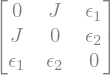

In [4]:
J = sp.Symbol("J", real=True, positive=True)
epsilon = sp.Symbol("epsilon", real=True, positive=True)
epsilon1 = sp.Symbol("epsilon1", real=True, positive=True)
epsilon2 = sp.Symbol("epsilon2", real=True, positive=True)
gamma = sp.Symbol("Gamma", real=True, positive=True)
delta = sp.Symbol("delta", real=True, positive=True)

N = 3 # number of sites
manifold = [3,5,6] # the rows/columns of the generic jump operators which correspond to our desired manifold

# building system hamiltonian
H = sp.Matrix([[0, J, epsilon1],[J, 0, epsilon2],[epsilon1, epsilon2, 0]])
H

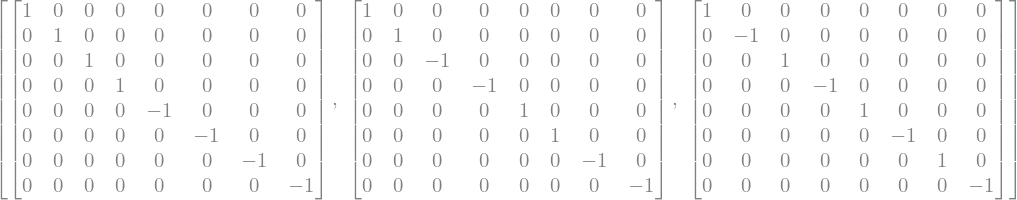

In [5]:
# returns jump operators in full 8-dimensional manifold
L_operators_full = [sigma(sigma_z, i, N) for i in range(N)]

L_operators_full

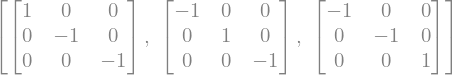

In [6]:
# projecting the jump operators onto the two-excitation manifold
L_operators_proj = [sp.Matrix(N, N, lambda i, j: operator[manifold[i], manifold[j]]) for operator in L_operators_full]
L_operators_proj

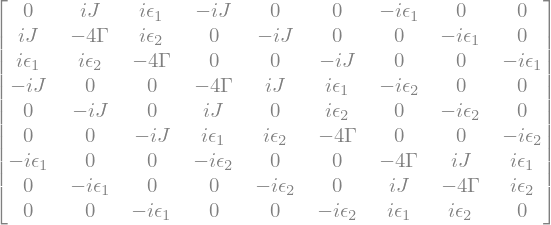

In [7]:
# constructing lindbladian
L, rho = lindbladian(N, output=False, degenerate=True, H=H, L_operators=L_operators_proj)
L = L.subs({sp.Symbol(f"Gamma_{i}", real=True, nonnegative=True): gamma for i in range(N)})

L

In [8]:
mathematica_code(L).replace("Gamma","Γ").replace("epsilon1", "ϵ").replace("epsilon2", "α")

'{{0, I*J, I*ϵ, -I*J, 0, 0, -I*ϵ, 0, 0}, {I*J, -4*Γ, I*α, 0, -I*J, 0, 0, -I*ϵ, 0}, {I*ϵ, I*α, -4*Γ, 0, 0, -I*J, 0, 0, -I*ϵ}, {-I*J, 0, 0, -4*Γ, I*J, I*ϵ, -I*α, 0, 0}, {0, -I*J, 0, I*J, 0, I*α, 0, -I*α, 0}, {0, 0, -I*J, I*ϵ, I*α, -4*Γ, 0, 0, -I*α}, {-I*ϵ, 0, 0, -I*α, 0, 0, -4*Γ, I*J, I*ϵ}, {0, -I*ϵ, 0, 0, -I*α, 0, I*J, -4*Γ, I*α}, {0, 0, -I*ϵ, 0, 0, -I*α, I*ϵ, I*α, 0}}'

In [7]:
evals_string = '''
{0, -4*\[CapitalGamma], (-12*\[CapitalGamma]*(\[Alpha]^2 + \[Epsilon]^2))/(J^2 + 16*\[CapitalGamma]^2), (6*J^4*(10*\[CapitalGamma] + 3*Sqrt[-J^2 + \[CapitalGamma]^2]) - 16*\[CapitalGamma]^2*(\[CapitalGamma] + Sqrt[-J^2 + \[CapitalGamma]^2])*(\[Alpha]^2 + \[Epsilon]^2) + 
   J^2*(-60*\[CapitalGamma]^3 + 9*\[Alpha]^2*Sqrt[-J^2 + \[CapitalGamma]^2] - 68*\[CapitalGamma]^2*Sqrt[-J^2 + \[CapitalGamma]^2] + 9*Sqrt[-J^2 + \[CapitalGamma]^2]*\[Epsilon]^2 + 21*\[CapitalGamma]*(\[Alpha]^2 + \[Epsilon]^2)))/
  (9*J^4 + 64*\[CapitalGamma]^3*(\[CapitalGamma] + Sqrt[-J^2 + \[CapitalGamma]^2]) - J^2*\[CapitalGamma]*(73*\[CapitalGamma] + 39*Sqrt[-J^2 + \[CapitalGamma]^2])), (-12*\[CapitalGamma]*(\[Alpha]^2 + \[Epsilon]^2))/(J^2 + 16*\[CapitalGamma]^2), 
 -1/2*((6*I)*J^5 + 40*J^4*\[CapitalGamma] + (16*I)*J*\[CapitalGamma]^2*(\[Alpha]^2 + \[Epsilon]^2) - 16*J^2*\[CapitalGamma]*(\[Alpha]^2 - 8*\[CapitalGamma]^2 + \[Epsilon]^2) + I*J^3*(3*\[Alpha]^2 - 32*\[CapitalGamma]^2 + 3*\[Epsilon]^2) + 
    (6*I)*Sqrt[J^4*(-16*\[Alpha]^4*\[CapitalGamma]^2 + \[Alpha]^2*(9*J^2 - (24*I)*J*\[CapitalGamma] + 16*\[CapitalGamma]^2)*\[Epsilon]^2 - 16*\[CapitalGamma]^2*\[Epsilon]^4)])/(J^2*(3*J^2 - (8*I)*J*\[CapitalGamma] + 16*\[CapitalGamma]^2)), 
 -1/2*((6*I)*J^5 + 40*J^4*\[CapitalGamma] + (16*I)*J*\[CapitalGamma]^2*(\[Alpha]^2 + \[Epsilon]^2) - 16*J^2*\[CapitalGamma]*(\[Alpha]^2 - 8*\[CapitalGamma]^2 + \[Epsilon]^2) + I*J^3*(3*\[Alpha]^2 - 32*\[CapitalGamma]^2 + 3*\[Epsilon]^2) - 
    (6*I)*Sqrt[J^4*(-16*\[Alpha]^4*\[CapitalGamma]^2 + \[Alpha]^2*(9*J^2 - (24*I)*J*\[CapitalGamma] + 16*\[CapitalGamma]^2)*\[Epsilon]^2 - 16*\[CapitalGamma]^2*\[Epsilon]^4)])/(J^2*(3*J^2 - (8*I)*J*\[CapitalGamma] + 16*\[CapitalGamma]^2)), 
 (J^4*(60*\[CapitalGamma] - 18*Sqrt[-J^2 + \[CapitalGamma]^2]) + 16*\[CapitalGamma]^2*(-\[CapitalGamma] + Sqrt[-J^2 + \[CapitalGamma]^2])*(\[Alpha]^2 + \[Epsilon]^2) + 
   J^2*(-60*\[CapitalGamma]^3 - 9*\[Alpha]^2*Sqrt[-J^2 + \[CapitalGamma]^2] + 68*\[CapitalGamma]^2*Sqrt[-J^2 + \[CapitalGamma]^2] - 9*Sqrt[-J^2 + \[CapitalGamma]^2]*\[Epsilon]^2 + 21*\[CapitalGamma]*(\[Alpha]^2 + \[Epsilon]^2)))/
  (9*J^4 + 64*\[CapitalGamma]^3*(\[CapitalGamma] - Sqrt[-J^2 + \[CapitalGamma]^2]) + J^2*\[CapitalGamma]*(-73*\[CapitalGamma] + 39*Sqrt[-J^2 + \[CapitalGamma]^2])), 
 ((6*I)*J^5 - 40*J^4*\[CapitalGamma] + (16*I)*J*\[CapitalGamma]^2*(\[Alpha]^2 + \[Epsilon]^2) + 16*J^2*\[CapitalGamma]*(\[Alpha]^2 - 8*\[CapitalGamma]^2 + \[Epsilon]^2) + I*J^3*(3*\[Alpha]^2 - 32*\[CapitalGamma]^2 + 3*\[Epsilon]^2) - 
   (6*I)*Sqrt[J^4*(-16*\[Alpha]^4*\[CapitalGamma]^2 + \[Alpha]^2*(9*J^2 + (24*I)*J*\[CapitalGamma] + 16*\[CapitalGamma]^2)*\[Epsilon]^2 - 16*\[CapitalGamma]^2*\[Epsilon]^4)])/(2*J^2*(3*J^2 + (8*I)*J*\[CapitalGamma] + 16*\[CapitalGamma]^2))}
'''

<>:2: SyntaxWarning: invalid escape sequence '\['
<>:2: SyntaxWarning: invalid escape sequence '\['
/tmp/ipykernel_886/2878499447.py:2: SyntaxWarning: invalid escape sequence '\['
  {0, -4*\[CapitalGamma], (-12*\[CapitalGamma]*(\[Alpha]^2 + \[Epsilon]^2))/(J^2 + 16*\[CapitalGamma]^2), (6*J^4*(10*\[CapitalGamma] + 3*Sqrt[-J^2 + \[CapitalGamma]^2]) - 16*\[CapitalGamma]^2*(\[CapitalGamma] + Sqrt[-J^2 + \[CapitalGamma]^2])*(\[Alpha]^2 + \[Epsilon]^2) +


# eigenvalues approximated to $O(\epsilon_i^3)$

++++++++++++++++++++++++++++++


++++++++++++++++++++++++++++++


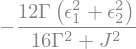

++++++++++++++++++++++++++++++


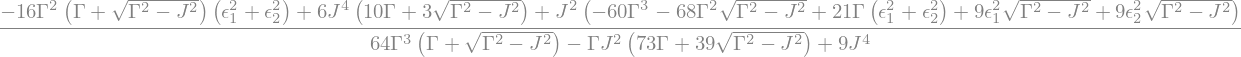

++++++++++++++++++++++++++++++


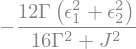

++++++++++++++++++++++++++++++


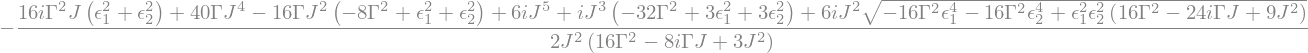

++++++++++++++++++++++++++++++


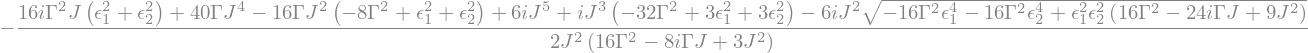

++++++++++++++++++++++++++++++


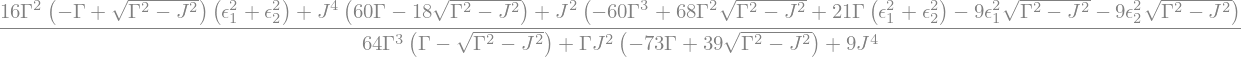

++++++++++++++++++++++++++++++


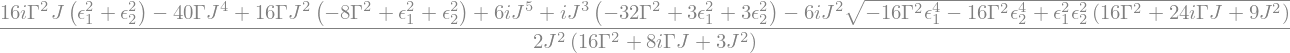

++++++++++++++++++++++++++++++


In [8]:
evals_approx = list(parse_mathematica(evals_string.replace(r"\[CapitalGamma]", "Gamma").replace(r"\[Epsilon]", "epsilon1").replace(r"\[Alpha]", "epsilon2")))

evals_approx = [i.subs({sp.Symbol("Gamma"): gamma, sp.Symbol("epsilon1"): epsilon1, sp.Symbol("epsilon2"): epsilon2, sp.Symbol("J"): J}) for i in evals_approx]


for i in evals_approx:
    #display(sp.re(i.subs({gamma:1e-6, J : 0.1, epsilon1:1e-4, epsilon2:1e-4})))
    display(i)
    print("++++++++++++++++++++++++++++++")

# big $\Gamma$ limit

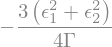

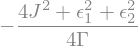

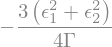

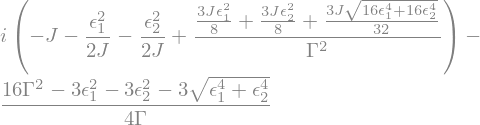

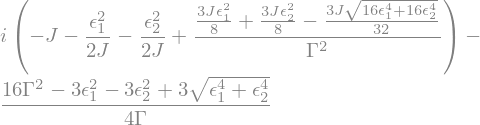

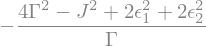

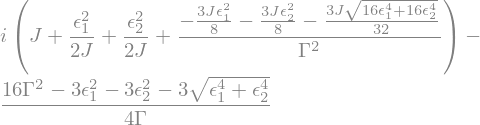

In [12]:
# big gamma limit - second order in eta=1/gamma
evals_big_gamma = []
for i in evals_approx:
    i = i.subs(gamma, 1/sp.Symbol('eta')).series(sp.Symbol('eta'), 0, 3).subs({sp.Symbol('eta'): 1/gamma, epsilon1**2*epsilon2**2: 0}).removeO()
    evals_big_gamma.append(i)
    display(sp.Add((sp.re(i).factor()),sp.I*(sp.im(i)), evaluate=(True if sp.im(i)==0 else False)))
    

# small $\Gamma$ limit

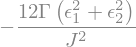

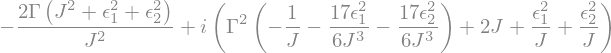

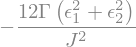

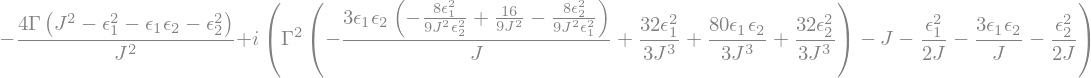

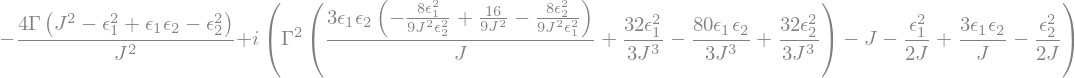

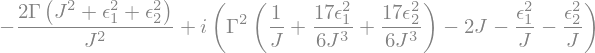

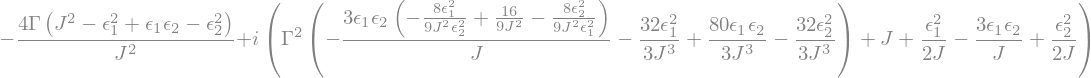

In [11]:
# small gamma limit - second order
evals_small_gamma = []
for i in evals_approx:
    i = i.series(gamma, 0, 3).subs(epsilon1**2*epsilon2**2, 0).removeO()
    evals_small_gamma.append(i)
    display(sp.Add((sp.re(i).factor()),sp.I*(sp.im(i)), evaluate=(True if sp.im(i)==0 else False)))

# case 1: set $\epsilon_1=\epsilon_2=\epsilon$

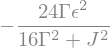

In [11]:
# general
evals_approx[2].subs({epsilon1:epsilon, epsilon2: epsilon})

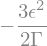

In [12]:
# big gamma
evals_big_gamma[2].subs({epsilon1:epsilon, epsilon2: epsilon})

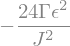

In [13]:
# small gamma
evals_small_gamma[2].subs({epsilon1:epsilon, epsilon2: epsilon})

# case 2: set $\epsilon_1=0$ and $\epsilon_2=\epsilon$

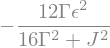

In [14]:
# general
evals_approx[2].subs({epsilon1:0, epsilon2: epsilon})

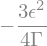

In [15]:
# big gamma
evals_big_gamma[2].subs({epsilon1:0, epsilon2: epsilon})

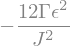

In [16]:
# small gamma
evals_small_gamma[2].subs({epsilon1:0, epsilon2: epsilon})

# case 3: set $\epsilon_1 = \epsilon + \delta$ and $\epsilon_2 = \epsilon - \delta$

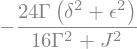

In [17]:
# general
evals_approx[2].subs({epsilon1:epsilon+delta, epsilon2:epsilon-delta}).expand().factor()

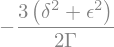

In [18]:
# big gamma
evals_big_gamma[2].subs({epsilon1:epsilon+delta, epsilon2:epsilon-delta}).expand().factor()

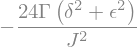

In [19]:
# small gamma
evals_small_gamma[2].subs({epsilon1:epsilon+delta, epsilon2:epsilon-delta}).expand().factor()